In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Raw Gold Prices Data

## Data Understanding & EDA

In [63]:
df = pd.read_csv('../data/raw/gold_prices.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2016-03-14,1244.400024,1258.000000,1234.500000,1256.000000,58
1,2016-03-15,1230.400024,1236.000000,1228.000000,1228.300049,37
2,2016-03-16,1229.300049,1263.800049,1228.900024,1229.500000,45
3,2016-03-17,1264.500000,1270.099976,1255.900024,1261.500000,27
4,2016-03-18,1253.800049,1264.400024,1251.500000,1257.099976,542


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2513 non-null   str    
 1   Close   2513 non-null   float64
 2   High    2513 non-null   float64
 3   Low     2513 non-null   float64
 4   Open    2513 non-null   float64
 5   Volume  2513 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 117.9 KB


## Missing Values

In [65]:
df.isna().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Dulplicate

In [66]:
df["Date"].duplicated().sum()

np.int64(0)

## Range

In [67]:
df["Date"].min(), df["Date"].max()

('2016-03-14', '2026-03-12')

## Plot Harga Emas

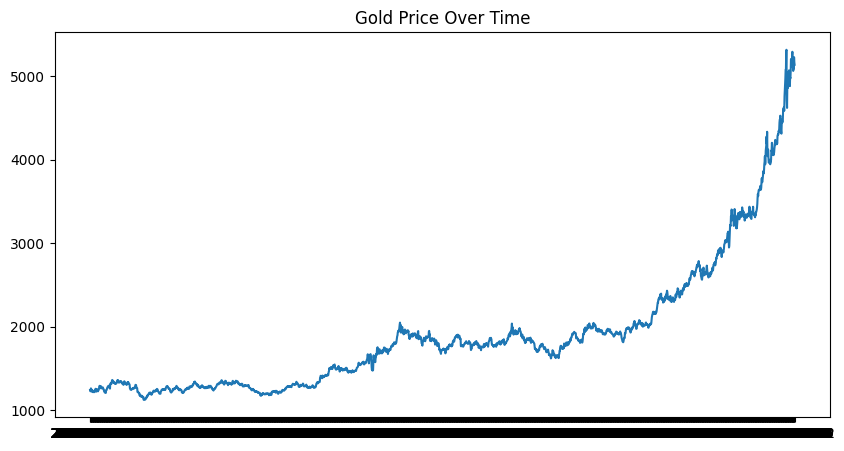

In [68]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Close"])
plt.title("Gold Price Over Time")
plt.show()

## Histogram Daily Rolling

<Axes: >

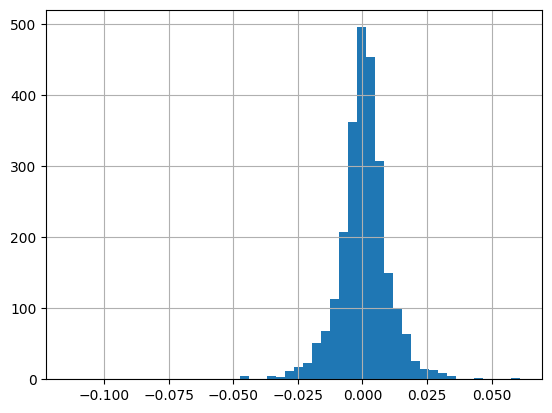

In [69]:
df["return"] = df["Close"].pct_change()
df["return"].hist(bins=50)

## Rolling Volatility

In [70]:
df["volatility"] = df["return"].rolling(20).std()

In [71]:
df["volatility"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
2508    0.018514
2509    0.018377
2510    0.018812
2511    0.018902
2512    0.018758
Name: volatility, Length: 2513, dtype: float64

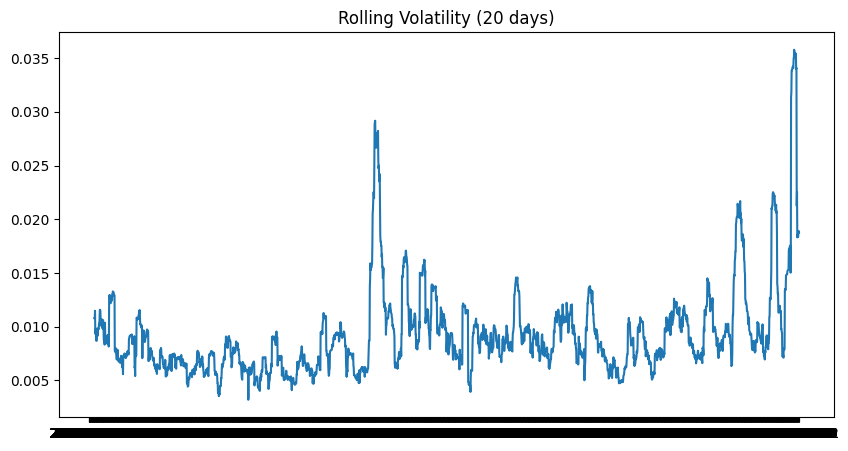

In [72]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["volatility"])
plt.title("Rolling Volatility (20 days)")
plt.show()

# Preprocessed Gold Prices Data

## Understanding

In [73]:
df_preprocessed = pd.read_csv('../data/processed/gold_features.csv')
df_preprocessed.head()

,Date,Close,High,Low,Open,Volume,return,lag_1,lag_2,lag_3,lag_5,lag_7,lag_10,rolling_mean_7,rolling_std_7,volatility_20,target
0,2016-04-04,1218.000000,1222.300049,1215.000000,1221.699951,2038,-0.003436,1222.199951,1234.199951,1226.900024,1219.900024,1223.699951,1253.800049,1225.457136,7.011368,0.010751,1228.400024
1,2016-04-05,1228.400024,1236.699951,1215.400024,1215.400024,477,0.008539,1218.000000,1222.199951,1234.199951,1235.599976,1221.400024,1243.800049,1226.457136,6.833205,0.010973,1222.500000
2,2016-04-06,1222.500000,1230.400024,1217.599976,1230.400024,248,-0.004803,1228.400024,1218.000000,1222.199951,1226.900024,1219.900024,1248.199951,1226.828561,6.478859,0.010999,1236.199951
3,2016-04-07,1236.199951,1242.900024,1224.599976,1224.800049,375,0.011207,1222.500000,1228.400024,1218.000000,1234.199951,1235.599976,1223.699951,1226.914272,6.616740,0.011335,1242.500000
4,2016-04-08,1242.500000,1242.800049,1232.000000,1241.000000,409,0.005096,1236.199951,1222.500000,1228.400024,1222.199951,1226.900024,1221.400024,1229.142840,8.858486,0.011010,1256.699951


In [74]:
df_preprocessed.info()

<class 'pandas.DataFrame'>
RangeIndex: 2492 entries, 0 to 2491
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2492 non-null   str    
 1   Close           2492 non-null   float64
 2   High            2492 non-null   float64
 3   Low             2492 non-null   float64
 4   Open            2492 non-null   float64
 5   Volume          2492 non-null   int64  
 6   return          2492 non-null   float64
 7   lag_1           2492 non-null   float64
 8   lag_2           2492 non-null   float64
 9   lag_3           2492 non-null   float64
 10  lag_5           2492 non-null   float64
 11  lag_7           2492 non-null   float64
 12  lag_10          2492 non-null   float64
 13  rolling_mean_7  2492 non-null   float64
 14  rolling_std_7   2492 non-null   float64
 15  volatility_20   2492 non-null   float64
 16  target          2492 non-null   float64
dtypes: float64(15), int64(1), str(1)
memory usag

In [75]:
df_preprocessed.describe()

,Close,High,Low,Open,Volume,return,lag_1,lag_2,lag_3,lag_5,lag_7,lag_10,rolling_mean_7,rolling_std_7,volatility_20,target
count,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000,2492.000000
mean,1899.219942,1909.076967,1888.951926,1898.862240,5098.550161,0.000625,1897.660873,1896.031579,1894.424998,1891.243859,1888.067534,1883.542695,1894.441411,20.007818,0.009229,1900.796066
std,767.641791,775.614439,759.373080,767.658145,28286.688223,0.010122,765.064475,762.145586,759.328330,753.789354,748.238943,740.685263,758.906406,21.840001,0.004175,770.270228
min,1127.800049,1132.800049,1123.900024,1126.900024,0.000000,-0.113662,1127.800049,1127.800049,1127.800049,1127.800049,1127.800049,1127.800049,1132.414307,1.133456,0.003199,1127.800049
25%,1313.099976,1316.700043,1310.049988,1312.199951,54.000000,-0.004026,1313.024994,1312.775024,1312.574951,1312.149963,1311.924988,1311.599976,1312.224997,8.952780,0.006795,1313.250031
50%,1775.800049,1786.700012,1768.800049,1777.500000,214.000000,0.000705,1775.750000,1775.649963,1775.399963,1774.700012,1774.100037,1773.599976,1777.185713,13.772160,0.008337,1775.850037
75%,1982.149994,1988.899994,1972.925018,1981.375031,656.250000,0.005854,1981.724976,1981.599976,1981.149994,1980.400024,1979.274963,1978.174988,1978.075003,22.879208,0.010246,1982.350037
max,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000,0.060833,5318.399902,5318.399902,5318.399902,5318.399902,5318.399902,5318.399902,5196.528530,270.387055,0.035774,5318.399902


In [76]:
print(df_preprocessed[["Close","target"]].head(20))

          Close       target
0   1218.000000  1228.400024
1   1228.400024  1222.500000
2   1222.500000  1236.199951
3   1236.199951  1242.500000
4   1242.500000  1256.699951
5   1256.699951  1259.400024
6   1259.400024  1246.800049
7   1246.800049  1225.000000
8   1225.000000  1233.099976
9   1233.099976  1233.599976
10  1233.599976  1253.000000
11  1253.000000  1253.199951
12  1253.199951  1249.000000
13  1249.000000  1228.699951
14  1228.699951  1238.900024
15  1238.900024  1242.199951
16  1242.199951  1249.199951
17  1249.199951  1265.500000
18  1265.500000  1289.199951
19  1289.199951  1294.699951


# Oil Prices

In [77]:
oil_prices = pd.read_csv('../data/raw/oil_prices.csv')
oil_prices.head()

,Date,oil_price
0,2016-03-14,37.180000
1,2016-03-15,36.340000
2,2016-03-16,38.459999
3,2016-03-17,40.200001
4,2016-03-18,39.439999


In [78]:
oil_prices.tail()

,Date,oil_price
2509,2026-03-06,90.900002
2510,2026-03-09,94.769997
2511,2026-03-10,83.449997
2512,2026-03-11,87.250000
2513,2026-03-12,94.980003


In [79]:
oil_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2514 non-null   str    
 1   oil_price  2514 non-null   float64
dtypes: float64(1), str(1)
memory usage: 39.4 KB


### Range Date

In [80]:
oil_prices["Date"].min()

'2016-03-14'

In [81]:
oil_prices["Date"].max()

'2026-03-12'

### Missing Values

In [82]:
oil_prices.isna().sum()

Date         0
oil_price    0
dtype: int64

### Distribusi

In [95]:
oil_prices.describe()

,oil_price
count,2514.000000
mean,64.255147
std,17.011567
min,-37.630001
25%,52.287499
50%,63.689999
75%,74.362501
max,123.699997


# FRED Data

In [83]:
fred = pd.read_csv('../data/raw/macro_fred.csv')
fred.head(5)

,Date,cpi,fed_rate,usd_index
0,2016-03-14,NaN,0.36,112.1688
1,2016-03-15,NaN,0.37,112.5545
2,2016-03-16,NaN,0.37,112.7759
3,2016-03-17,NaN,0.37,110.4450
4,2016-03-18,NaN,0.37,110.4002


In [84]:
fred.tail()

,Date,cpi,fed_rate,usd_index
3644,2026-03-06,NaN,3.64,119.491
3645,2026-03-07,NaN,3.64,NaN
3646,2026-03-08,NaN,3.64,NaN
3647,2026-03-09,NaN,3.64,NaN
3648,2026-03-10,NaN,3.64,NaN


Cleaning: ambil data yang 10 tahun terakhir dari tanggal prediksi gold nya aja

In [85]:
fred.info()

<class 'pandas.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3649 non-null   str    
 1   cpi        118 non-null    float64
 2   fed_rate   3649 non-null   float64
 3   usd_index  2491 non-null   float64
dtypes: float64(3), str(1)
memory usage: 114.2 KB


In [86]:
fred["Date"] = pd.to_datetime(fred["Date"])

In [87]:
fred_2023 = fred[fred["Date"].dt.year == 2023]

fred_2023.head()

,Date,cpi,fed_rate,usd_index
2484,2023-01-01,300.42,4.33,NaN
2485,2023-01-02,NaN,4.33,NaN
2486,2023-01-03,NaN,4.33,122.0905
2487,2023-01-04,NaN,4.33,121.5008
2488,2023-01-05,NaN,4.33,122.1017


Cleaning: nilai cpi berlaku sampai ada update baru. karena fed rate dan usd emang bulanan, jadi ya buat per bulan aja biar enak

### Range Date

In [88]:
fred["Date"].min()

Timestamp('2016-03-14 00:00:00')

In [89]:
fred["Date"].max()

Timestamp('2026-03-10 00:00:00')

### Missing Value

In [90]:
fred.isna().sum()

Date            0
cpi          3531
fed_rate        0
usd_index    1158
dtype: int64

<Axes: xlabel='Date'>

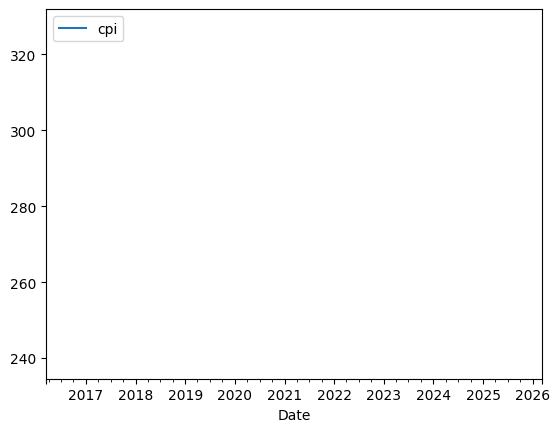

In [91]:
fred.plot(x="Date", y="cpi")

<Axes: xlabel='Date'>

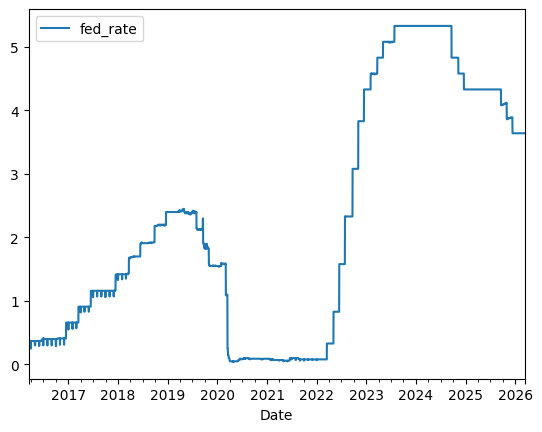

In [92]:
fred.plot(x="Date", y="fed_rate")

<Axes: xlabel='Date'>

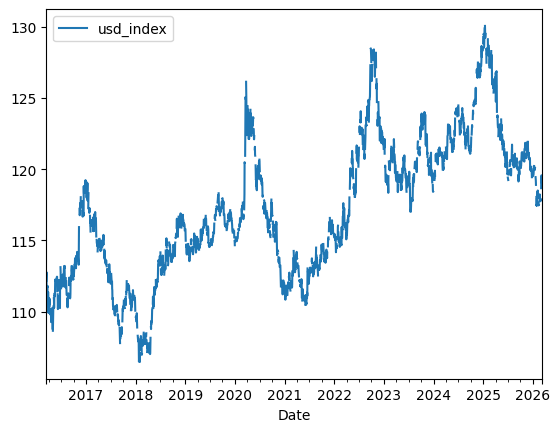

In [93]:
fred.plot(x="Date", y="usd_index")

### Distribusi

In [94]:
fred.describe()

,Date,cpi,fed_rate,usd_index
count,3649,118.000000,3649.000000,2491.000000
mean,2021-03-12 00:00:00,276.910034,2.254990,117.197380
min,2016-03-14 00:00:00,238.992000,0.040000,106.487700
25%,2018-09-12 00:00:00,252.276750,0.400000,113.442950
50%,2021-03-12 00:00:00,264.270000,1.820000,116.603900
75%,2023-09-10 00:00:00,305.713750,4.330000,120.887050
max,2026-03-10 00:00:00,327.460000,5.330000,130.041300
std,NaN,29.017781,1.902602,4.888159


Cleaning (ringaksan):
1. Align date range dengan gold
2. Sort date
3. Forward fill macro data
4. Merge semua dataset
5. Forward fill lagi setelah merge

Feature Engineering (ringkasan):
1. Return / change
2. Lag macro
3. Real interest rate (feature penting)